<a href="https://colab.research.google.com/github/iiiyahiya111/Project/blob/main/week3_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# ============================================================
# CHECK ACTUAL ZIP FILE NAMES
# ============================================================

from pathlib import Path

print("ZIP files in /content:\n")

for p in Path("/content").glob("*.zip"):
    print(p)

print("\nZIP files in Google Drive:\n")

for p in Path("/content/drive/MyDrive").rglob("*.zip"):
    print(p)

ZIP files in /content:


ZIP files in Google Drive:

/content/drive/MyDrive/Win 11 Activator.zip
/content/drive/MyDrive/Crop Disease Segmentation.v1i.coco-segmentation.zip
/content/drive/MyDrive/Potato_Severity_Dataset.zip
/content/drive/MyDrive/Potato_Severity_Dataset_DEDUPED_FINAL.zip
/content/drive/MyDrive/Dataset_1_Image_Environment.zip
/content/drive/MyDrive/2.2 ICE/dado.zip
/content/drive/MyDrive/Rice_Disease_Project/Rice Leaf Disease Image Samples.zip
/content/drive/MyDrive/Rice_Disease_Project/Rice_Leaf_Disease_Segmentation_Masks.zip


In [ ]:
# Mount Drive
from google.colab import drive

drive.mount('/content/drive')

# **Cell 1 — Setup + Dataset Preparation**

In [27]:
# ============================================================
# CELL 1
# Setup + unzip + image/mask indexing + 144-step environment
# ============================================================

!pip -q install albumentations==2.0.8

import os
import random
import zipfile
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

import albumentations as A
from albumentations.pytorch import ToTensorV2

from google.colab import drive


# ------------------------------------------------------------
# Drive
# ------------------------------------------------------------
drive.mount("/content/drive")


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

IMG_SIZE = 224
SEQ_LEN = 144

BATCH_SIZE_IMG = 16
BATCH_SIZE_FUSION = 16

NUM_WORKERS = 2

EPOCHS = 20
PATIENCE = 4

LR = 1e-4
WEIGHT_DECAY = 1e-4

RESULTS_DIR = Path("/content/week3_seg_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("DEVICE:", DEVICE)


# ------------------------------------------------------------
# Locate ZIP files
# ------------------------------------------------------------
def locate_zip(exact_name=None, pattern=None):

    candidates = []

    if exact_name:
        candidates += list(
            Path("/content").glob(exact_name)
        )

        candidates += list(
            Path("/content/drive/MyDrive").rglob(exact_name)
        )

    if pattern:
        candidates += list(
            Path("/content").glob(pattern)
        )

        candidates += list(
            Path("/content/drive/MyDrive").rglob(pattern)
        )

    candidates = list(
        dict.fromkeys(map(str, candidates))
    )

    if not candidates:
        raise FileNotFoundError(
            f"ZIP not found.\n"
            f"Put the ZIP inside /content or Google Drive.\n"
            f"Expected: {exact_name or pattern}"
        )

    return Path(candidates[0])


SEG_ZIP = locate_zip(
    pattern="Potato_Severity_Dataset_DEDUPED_FINAL*.zip"
)

ENV_ZIP = locate_zip(
    exact_name="Dataset_1_Image_Environment.zip"
)

print("\nSegmentation ZIP:")
print(SEG_ZIP)

print("\nEnvironment ZIP:")
print(ENV_ZIP)


# ------------------------------------------------------------
# Extraction
# ------------------------------------------------------------
SEG_EXTRACT = Path("/content/week3_seg_dataset")
ENV_EXTRACT = Path("/content/week3_env_dataset")

for path in [SEG_EXTRACT, ENV_EXTRACT]:

    if path.exists():
        shutil.rmtree(path)

    path.mkdir(
        parents=True,
        exist_ok=True
    )


with zipfile.ZipFile(SEG_ZIP) as z:
    z.extractall(SEG_EXTRACT)

with zipfile.ZipFile(ENV_ZIP) as z:
    z.extractall(ENV_EXTRACT)


# ------------------------------------------------------------
# Locate files
# ------------------------------------------------------------
SEG_CSV = next(
    SEG_EXTRACT.rglob(
        "potato_severity_FINAL.csv"
    )
)

SEG_ROOT = SEG_CSV.parent.parent

ENV_HOURLY_CSV = (
    ENV_EXTRACT /
    "synthetic_environment_hourly.csv"
)

print("\nSegmentation root:")
print(SEG_ROOT)

print("\nEnvironment hourly:")
print(ENV_HOURLY_CSV)


# ------------------------------------------------------------
# Read segmentation metadata
# ------------------------------------------------------------
meta = pd.read_csv(SEG_CSV)

print(
    "\nRaw segmentation metadata:",
    meta.shape
)


# ------------------------------------------------------------
# Rebuild actual image/mask paths
# Missing image or mask -> SKIP
# ------------------------------------------------------------
rows = []

for _, r in meta[
    [
        "split",
        "filename",
        "class_name",
        "severity_percent"
    ]
].iterrows():

    fn = r["filename"]
    split = r["split"]

    stem = Path(fn).stem

    root = (
        SEG_ROOT /
        "segmentation" /
        split
    )

    image_path = (
        root /
        "images" /
        fn
    )

    lesion_mask_path = (
        root /
        "lesion_masks" /
        f"{stem}.png"
    )

    if (
        image_path.exists()
        and lesion_mask_path.exists()
    ):

        rows.append({
            **r.to_dict(),

            "image_file":
                str(image_path),

            "mask_file":
                str(lesion_mask_path),
        })


image_df = pd.DataFrame(rows).reset_index(
    drop=True
)

print(
    "\nUsable image-mask pairs:",
    len(image_df)
)

print(
    "Split:",
    image_df["split"].value_counts().to_dict()
)

print(
    "Skipped missing image/mask rows:",
    len(meta) - len(image_df)
)


# ------------------------------------------------------------
# Environment data
#
# We only use:
# temperature
# RH
# RH >= 90 indicator
#
# We DO NOT use:
# severity_percent
# class_name
# SIMCAST
# Wallin SV
# latent_risk
# etc.
# ------------------------------------------------------------

valid_ids = set(
    image_df["filename"].astype(str)
)

usecols = [
    "image_id",
    "candidate_id",
    "hour",
    "temperature",
    "rh",
    "rh_ge90"
]

dtypes = {
    "image_id": "string",
    "candidate_id": "int8",
    "hour": "int16",
    "temperature": "float32",
    "rh": "float32",
    "rh_ge90": "boolean",
}


# ------------------------------------------------------------
# Read in chunks to reduce RAM usage
# ------------------------------------------------------------
chunks = []

for chunk in pd.read_csv(
    ENV_HOURLY_CSV,
    usecols=usecols,
    dtype=dtypes,
    chunksize=400_000
):

    chunk = chunk[
        (chunk["hour"] < SEQ_LEN)
        &
        chunk["image_id"].isin(valid_ids)
    ]

    if len(chunk) > 0:
        chunks.append(chunk)


env_df = pd.concat(
    chunks,
    ignore_index=True
)


env_df["rh_ge90"] = (
    env_df["rh_ge90"]
    .astype("float32")
)


# ------------------------------------------------------------
# Sort
# ------------------------------------------------------------
env_df = env_df.sort_values(
    [
        "image_id",
        "candidate_id",
        "hour"
    ]
).reset_index(drop=True)


# ------------------------------------------------------------
# Keep only complete 144-step sequences
# ------------------------------------------------------------
group_sizes = (
    env_df
    .groupby(
        [
            "image_id",
            "candidate_id"
        ]
    )
    .size()
)

valid_pairs = group_sizes[
    group_sizes == SEQ_LEN
].index

valid_pair_set = set(valid_pairs)


pair_index = (
    env_df
    .set_index(
        [
            "image_id",
            "candidate_id"
        ]
    )
    .index
)

env_df = env_df[
    pair_index.isin(valid_pair_set)
].reset_index(drop=True)


# ------------------------------------------------------------
# Build sequence array
#
# Shape:
# [number_of_pairs, 144, 3]
#
# 3 features:
# temperature
# RH
# RH>=90
# ------------------------------------------------------------
pair_keys = (
    env_df[
        [
            "image_id",
            "candidate_id"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

assert (
    len(env_df)
    ==
    len(pair_keys) * SEQ_LEN
), "144-step sequences are incomplete."


env_array = (
    env_df[
        [
            "temperature",
            "rh",
            "rh_ge90"
        ]
    ]
    .to_numpy(np.float32)
    .reshape(
        len(pair_keys),
        SEQ_LEN,
        3
    )
)


print(
    "\nValid image-candidate sequences:",
    len(pair_keys)
)

print(
    "Environment array shape:",
    env_array.shape
)

print(
    "Expected complete pairs:",
    len(valid_ids) * 10
)

print(
    "Missing/incomplete pairs:",
    len(valid_ids) * 10
    -
    len(pair_keys)
)


# ------------------------------------------------------------
# Train-only normalization
# ------------------------------------------------------------
split_map = (
    image_df
    .set_index("filename")["split"]
    .to_dict()
)

pair_splits = np.array([
    split_map[x]
    for x in pair_keys["image_id"]
])


train_pair_mask = (
    pair_splits == "train"
)


env_mean = (
    env_array[
        train_pair_mask,
        :, :2
    ]
    .reshape(-1, 2)
    .mean(axis=0)
)

env_std = (
    env_array[
        train_pair_mask,
        :, :2
    ]
    .reshape(-1, 2)
    .std(axis=0)
)

env_std = np.maximum(
    env_std,
    1e-6
)


# Normalize only temperature + RH
env_array[:, :, :2] = (
    env_array[:, :, :2]
    -
    env_mean
) / env_std


# ------------------------------------------------------------
# Lookup dictionaries
# ------------------------------------------------------------
image_lookup = (
    image_df
    .set_index("filename")
    .to_dict("index")
)


print("\nTrain environment mean:")
print(env_mean)

print("\nTrain environment std:")
print(env_std)

print("\nCell 1 complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DEVICE: cuda

Segmentation ZIP:
/content/drive/MyDrive/Potato_Severity_Dataset_DEDUPED_FINAL.zip

Environment ZIP:
/content/drive/MyDrive/Dataset_1_Image_Environment.zip

Segmentation root:
/content/week3_seg_dataset/Potato_Severity_Dataset_FINAL

Environment hourly:
/content/week3_env_dataset/synthetic_environment_hourly.csv

Raw segmentation metadata: (1108, 24)

Usable image-mask pairs: 1108
Split: {'train': 895, 'valid': 107, 'test': 106}
Skipped missing image/mask rows: 0

Valid image-candidate sequences: 11080
Environment array shape: (11080, 144, 3)
Expected complete pairs: 11080
Missing/incomplete pairs: 0

Train environment mean:
[15.222381 80.247116]

Train environment std:
[3.2486353 7.097013 ]

Cell 1 complete.


# **Cell 2 — Dataset + EfficientNet-B0 U-Net + GRU Fusion**

In [28]:
# ============================================================
# CELL 2
# Dataset + EfficientNet-B0 U-Net + GRU fusion model
# ============================================================

IMG_MEAN = (
    0.485,
    0.456,
    0.406
)

IMG_STD = (
    0.229,
    0.224,
    0.225
)


# ------------------------------------------------------------
# Augmentation
# ------------------------------------------------------------
def train_tfms():

    return A.Compose([
        A.Resize(
            IMG_SIZE,
            IMG_SIZE
        ),

        A.HorizontalFlip(p=0.5),

        A.VerticalFlip(p=0.2),

        A.Rotate(
            limit=15,
            border_mode=cv2.BORDER_REFLECT_101,
            p=0.5
        ),

        A.Normalize(
            mean=IMG_MEAN,
            std=IMG_STD
        ),

        ToTensorV2(),
    ])


def val_tfms():

    return A.Compose([
        A.Resize(
            IMG_SIZE,
            IMG_SIZE
        ),

        A.Normalize(
            mean=IMG_MEAN,
            std=IMG_STD
        ),

        ToTensorV2(),
    ])


# ------------------------------------------------------------
# IMAGE-ONLY DATASET
# ------------------------------------------------------------
class ImageSegDataset(Dataset):

    def __init__(
        self,
        df,
        transform
    ):

        self.df = (
            df
            .reset_index(drop=True)
        )

        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        r = self.df.iloc[idx]

        image = cv2.imread(
            r.image_file
        )

        mask = cv2.imread(
            r.mask_file,
            cv2.IMREAD_GRAYSCALE
        )

        if image is None:
            raise FileNotFoundError(
                r.image_file
            )

        if mask is None:
            raise FileNotFoundError(
                r.mask_file
            )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        mask = (
            mask > 127
        ).astype(np.uint8)


        out = self.transform(
            image=image,
            mask=mask
        )


        return {
            "image":
                out["image"],

            "mask":
                out["mask"]
                .float()
                .unsqueeze(0),

            "image_id":
                r.filename,
        }


# ------------------------------------------------------------
# Build image + environment pair table
# ------------------------------------------------------------
pair_rows = []

for i, r in pair_keys.iterrows():

    image_id = r.image_id

    if image_id not in image_lookup:
        continue

    pair_rows.append({

        "image_id":
            image_id,

        "candidate_id":
            int(r.candidate_id),

        "split":
            split_map[image_id],

        "env_idx":
            i,

        "image_file":
            image_lookup[image_id]["image_file"],

        "mask_file":
            image_lookup[image_id]["mask_file"],
    })


fusion_df = pd.DataFrame(
    pair_rows
)


print(
    "Fusion pairs:",
    len(fusion_df)
)


# ------------------------------------------------------------
# FUSION DATASET
# ------------------------------------------------------------
class FusionSegDataset(Dataset):

    def __init__(
        self,
        df,
        transform
    ):

        self.df = (
            df
            .reset_index(drop=True)
        )

        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        r = self.df.iloc[idx]

        image = cv2.imread(
            r.image_file
        )

        mask = cv2.imread(
            r.mask_file,
            cv2.IMREAD_GRAYSCALE
        )

        if image is None:
            raise FileNotFoundError(
                r.image_file
            )

        if mask is None:
            raise FileNotFoundError(
                r.mask_file
            )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        mask = (
            mask > 127
        ).astype(np.uint8)


        out = self.transform(
            image=image,
            mask=mask
        )


        env = torch.from_numpy(
            env_array[
                int(r.env_idx)
            ]
        ).float()


        return {
            "image":
                out["image"],

            "mask":
                out["mask"]
                .float()
                .unsqueeze(0),

            "env":
                env,

            "image_id":
                r.image_id,
        }


# ------------------------------------------------------------
# U-NET BLOCKS
# ------------------------------------------------------------
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_ch,
        out_ch
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_ch,
                out_ch,
                3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_ch
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                out_ch,
                out_ch,
                3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_ch
            ),

            nn.ReLU(
                inplace=True
            ),
        )


    def forward(self, x):

        return self.block(x)


class UpBlock(nn.Module):

    def __init__(
        self,
        in_ch,
        skip_ch,
        out_ch
    ):

        super().__init__()

        self.conv = DoubleConv(
            in_ch + skip_ch,
            out_ch
        )


    def forward(
        self,
        x,
        skip
    ):

        x = F.interpolate(
            x,
            size=skip.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        x = torch.cat(
            [
                x,
                skip
            ],
            dim=1
        )

        return self.conv(x)


# ------------------------------------------------------------
# EfficientNet-B0 U-Net
# ------------------------------------------------------------
class EfficientUNet(nn.Module):

    def __init__(
        self,
        pretrained=True,
        fusion=False,
        env_hidden=128
    ):

        super().__init__()

        self.fusion = fusion


        weights = (
            EfficientNet_B0_Weights.DEFAULT
            if pretrained
            else None
        )


        try:

            self.encoder = (
                efficientnet_b0(
                    weights=weights
                ).features
            )

        except Exception as e:

            print(
                "Pretrained weights unavailable."
            )

            print(
                "Using random initialization.",
                e
            )

            self.encoder = (
                efficientnet_b0(
                    weights=None
                ).features
            )


        bottleneck_ch = 1280


        # ----------------------------------------------------
        # Environment encoder
        # ----------------------------------------------------
        if fusion:

            self.gru = nn.GRU(
                input_size=3,
                hidden_size=env_hidden,
                batch_first=True
            )


            self.env_proj = nn.Sequential(

                nn.Linear(
                    env_hidden,
                    128
                ),

                nn.ReLU(
                    inplace=True
                )
            )


            bottleneck_ch += 128


        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------
        self.up5 = UpBlock(
            bottleneck_ch,
            192,
            256
        )

        self.up4 = UpBlock(
            256,
            80,
            128
        )

        self.up3 = UpBlock(
            128,
            40,
            64
        )

        self.up2 = UpBlock(
            64,
            24,
            32
        )

        self.up1 = UpBlock(
            32,
            32,
            16
        )


        self.head = nn.Conv2d(
            16,
            1,
            1
        )


    # --------------------------------------------------------
    # EfficientNet feature extraction
    # --------------------------------------------------------
    def encode(self, x):

        x = self.encoder[0](x)
        s1 = x

        x = self.encoder[1](x)
        x = self.encoder[2](x)
        s2 = x

        x = self.encoder[3](x)
        s3 = x

        x = self.encoder[4](x)
        s4 = x

        x = self.encoder[5](x)
        x = self.encoder[6](x)
        s5 = x

        x = self.encoder[7](x)

        b = self.encoder[8](x)

        return (
            s1,
            s2,
            s3,
            s4,
            s5,
            b
        )


    # --------------------------------------------------------
    # Forward
    # --------------------------------------------------------
    def forward(
        self,
        image,
        env=None
    ):

        (
            s1,
            s2,
            s3,
            s4,
            s5,
            b
        ) = self.encode(image)


        # ----------------------------------------------------
        # Naive concatenation fusion
        # ----------------------------------------------------
        if self.fusion:

            if env is None:

                raise ValueError(
                    "Environment sequence required."
                )


            _, hidden = self.gru(
                env
            )


            env_feat = self.env_proj(
                hidden[-1]
            )


            env_feat = (
                env_feat
                .unsqueeze(-1)
                .unsqueeze(-1)
            )


            env_feat = env_feat.expand(
                -1,
                -1,
                b.shape[-2],
                b.shape[-1]
            )


            b = torch.cat(
                [
                    b,
                    env_feat
                ],
                dim=1
            )


        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------
        x = self.up5(
            b,
            s5
        )

        x = self.up4(
            x,
            s4
        )

        x = self.up3(
            x,
            s3
        )

        x = self.up2(
            x,
            s2
        )

        x = self.up1(
            x,
            s1
        )


        x = F.interpolate(
            x,
            size=(
                IMG_SIZE,
                IMG_SIZE
            ),
            mode="bilinear",
            align_corners=False
        )


        return self.head(x)


print("Cell 2 complete.")

Fusion pairs: 11080
Cell 2 complete.


# **Cell 3 — Loss + mIoU + Boundary-F1 + Training Engine**

In [29]:
# ============================================================
# CELL 3
# Loss + metrics + training/evaluation engine
# ============================================================


# ------------------------------------------------------------
# Dice Loss
# ------------------------------------------------------------
def dice_loss(
    logits,
    targets,
    eps=1e-6
):

    probs = torch.sigmoid(
        logits
    )

    intersection = (
        probs * targets
    ).sum(
        dim=(1,2,3)
    )

    denominator = (
        probs.sum(dim=(1,2,3))
        +
        targets.sum(dim=(1,2,3))
    )

    dice = (
        2 * intersection + eps
    ) / (
        denominator + eps
    )

    return 1 - dice.mean()


# ------------------------------------------------------------
# Combined segmentation loss
# ------------------------------------------------------------
def seg_loss(
    logits,
    targets
):

    bce = F.binary_cross_entropy_with_logits(
        logits,
        targets
    )

    dloss = dice_loss(
        logits,
        targets
    )

    return (
        0.5 * bce
        +
        0.5 * dloss
    )


# ------------------------------------------------------------
# IoU
# ------------------------------------------------------------
def binary_iou(
    pred,
    true
):

    pred = pred.astype(bool)
    true = true.astype(bool)

    intersection = (
        np.logical_and(
            pred,
            true
        ).sum()
    )

    union = (
        np.logical_or(
            pred,
            true
        ).sum()
    )

    if union == 0:
        return 1.0

    return intersection / union


def mean_iou(
    pred,
    true
):

    lesion_iou = binary_iou(
        pred,
        true
    )

    background_iou = binary_iou(
        ~pred.astype(bool),
        ~true.astype(bool)
    )

    miou = (
        lesion_iou
        +
        background_iou
    ) / 2

    return (
        miou,
        lesion_iou
    )


# ------------------------------------------------------------
# Boundary extraction
# ------------------------------------------------------------
def boundary_mask(
    mask,
    radius=1
):

    mask = mask.astype(
        np.uint8
    )

    kernel = np.ones(
        (
            2 * radius + 1,
            2 * radius + 1
        ),
        np.uint8
    )

    eroded = cv2.erode(
        mask,
        kernel,
        iterations=1
    )

    return (
        (mask > 0)
        &
        (eroded == 0)
    ).astype(np.uint8)


# ------------------------------------------------------------
# Boundary F1
# ------------------------------------------------------------
def boundary_f1(
    pred,
    true,
    tolerance=2
):

    pred_boundary = boundary_mask(
        pred
    )

    true_boundary = boundary_mask(
        true
    )


    if (
        pred_boundary.sum() == 0
        and
        true_boundary.sum() == 0
    ):
        return 1.0


    if (
        pred_boundary.sum() == 0
        or
        true_boundary.sum() == 0
    ):
        return 0.0


    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (
            2*tolerance+1,
            2*tolerance+1
        )
    )


    true_dilated = cv2.dilate(
        true_boundary,
        kernel
    )

    pred_dilated = cv2.dilate(
        pred_boundary,
        kernel
    )


    precision = (
        (
            pred_boundary
            &
            (true_dilated > 0)
        ).sum()
        /
        max(
            pred_boundary.sum(),
            1
        )
    )


    recall = (
        (
            true_boundary
            &
            (pred_dilated > 0)
        ).sum()
        /
        max(
            true_boundary.sum(),
            1
        )
    )


    return (
        2 * precision * recall
        /
        max(
            precision + recall,
            1e-8
        )
    )


# ------------------------------------------------------------
# Full metrics
# ------------------------------------------------------------
def compute_metrics_from_maps(
    prob_maps,
    gt_maps
):

    miou_values = []
    lesion_iou_values = []
    bf1_values = []


    for prob, gt in zip(
        prob_maps,
        gt_maps
    ):

        pred = (
            prob >= 0.5
        )


        miou, lesion_iou = mean_iou(
            pred,
            gt
        )


        bf1 = boundary_f1(
            pred.astype(np.uint8),
            gt.astype(np.uint8)
        )


        miou_values.append(
            miou
        )

        lesion_iou_values.append(
            lesion_iou
        )

        bf1_values.append(
            bf1
        )


    return {
        "mIoU":
            float(
                np.mean(miou_values)
            ),

        "Lesion_IoU":
            float(
                np.mean(
                    lesion_iou_values
                )
            ),

        "Boundary_F1":
            float(
                np.mean(
                    bf1_values
                )
            ),
    }


# ------------------------------------------------------------
# Evaluation
#
# For fusion:
# 10 trajectories / image
# are averaged into one image-level probability map.
# ------------------------------------------------------------
@torch.no_grad()
def evaluate(
    model,
    loader,
    fusion=False,
    aggregate_image=False
):

    model.eval()


    loss_sum = 0.0
    n_seen = 0


    if aggregate_image:

        prob_sum = {}
        count = {}
        gt_store = {}

    else:

        probs_all = []
        gt_all = []


    for batch in tqdm(
        loader,
        leave=False
    ):

        images = batch[
            "image"
        ].to(
            DEVICE,
            non_blocking=True
        )


        masks = batch[
            "mask"
        ].to(
            DEVICE,
            non_blocking=True
        )


        env = batch.get(
            "env"
        )


        if fusion:

            env = env.to(
                DEVICE,
                non_blocking=True
            )

            logits = model(
                images,
                env
            )

        else:

            logits = model(
                images
            )


        loss = seg_loss(
            logits,
            masks
        )


        batch_size = (
            images.size(0)
        )

        loss_sum += (
            loss.item()
            *
            batch_size
        )

        n_seen += batch_size


        probs = (
            torch.sigmoid(
                logits
            )
            .cpu()
            .numpy()[:,0]
        )


        gts = (
            masks
            .cpu()
            .numpy()[:,0]
        )


        # ----------------------------------------------------
        # Aggregate trajectories
        # ----------------------------------------------------
        if aggregate_image:

            for j, image_id in enumerate(
                batch["image_id"]
            ):

                if image_id not in prob_sum:

                    prob_sum[
                        image_id
                    ] = probs[j].copy()

                    count[
                        image_id
                    ] = 1

                    gt_store[
                        image_id
                    ] = gts[j].copy()

                else:

                    prob_sum[
                        image_id
                    ] += probs[j]

                    count[
                        image_id
                    ] += 1


        else:

            probs_all.extend(
                list(probs)
            )

            gt_all.extend(
                list(gts)
            )


    # --------------------------------------------------------
    # Convert trajectory predictions
    # to image-level predictions
    # --------------------------------------------------------
    if aggregate_image:

        probs_all = [
            prob_sum[k]
            /
            count[k]

            for k in prob_sum
        ]

        gt_all = [
            gt_store[k]

            for k in prob_sum
        ]


    metrics = compute_metrics_from_maps(
        probs_all,
        gt_all
    )


    metrics["loss"] = (
        loss_sum /
        max(
            n_seen,
            1
        )
    )


    metrics["N_images"] = len(
        gt_all
    )


    return metrics


# ------------------------------------------------------------
# Training
# ------------------------------------------------------------
def run_training(
    model,
    train_loader,
    val_loader,
    fusion,
    name
):

    model = model.to(
        DEVICE
    )


    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )


    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2
        )
    )


    scaler = torch.cuda.amp.GradScaler(
        enabled=(
            DEVICE.type == "cuda"
        )
    )


    history = []

    best_score = -1.0

    bad_epochs = 0


    checkpoint_path = (
        RESULTS_DIR
        /
        f"{name}_best.pt"
    )


    for epoch in range(
        1,
        EPOCHS + 1
    ):

        model.train()

        running_loss = 0.0
        n_samples = 0


        for batch in tqdm(
            train_loader,
            desc=(
                f"{name} "
                f"Epoch {epoch}/{EPOCHS}"
            ),
            leave=False
        ):


            images = batch[
                "image"
            ].to(
                DEVICE,
                non_blocking=True
            )


            masks = batch[
                "mask"
            ].to(
                DEVICE,
                non_blocking=True
            )


            env = batch.get(
                "env"
            )


            if fusion:

                env = env.to(
                    DEVICE,
                    non_blocking=True
                )


            optimizer.zero_grad(
                set_to_none=True
            )


            with torch.cuda.amp.autocast(
                enabled=(
                    DEVICE.type == "cuda"
                )
            ):

                if fusion:

                    logits = model(
                        images,
                        env
                    )

                else:

                    logits = model(
                        images
                    )


                loss = seg_loss(
                    logits,
                    masks
                )


            scaler.scale(
                loss
            ).backward()


            scaler.unscale_(
                optimizer
            )


            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                5.0
            )


            scaler.step(
                optimizer
            )

            scaler.update()


            running_loss += (
                loss.item()
                *
                images.size(0)
            )

            n_samples += (
                images.size(0)
            )


        train_loss = (
            running_loss
            /
            max(
                n_samples,
                1
            )
        )


        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------
        val_metrics = evaluate(
            model,
            val_loader,
            fusion=fusion,
            aggregate_image=fusion
        )


        monitor = val_metrics[
            "mIoU"
        ]


        scheduler.step(
            monitor
        )


        history.append({

            "epoch":
                epoch,

            "train_loss":
                train_loss,

            **{
                f"val_{k}": v
                for k, v
                in val_metrics.items()
            }
        })


        print(
            f"\nEpoch {epoch:02d}"
        )

        print(
            f"Train Loss: "
            f"{train_loss:.4f}"
        )

        print(
            f"Val mIoU: "
            f"{val_metrics['mIoU']:.4f}"
        )

        print(
            f"Val Lesion IoU: "
            f"{val_metrics['Lesion_IoU']:.4f}"
        )

        print(
            f"Val Boundary-F1: "
            f"{val_metrics['Boundary_F1']:.4f}"
        )


        # ----------------------------------------------------
        # Save best
        # ----------------------------------------------------
        if monitor > best_score:

            best_score = monitor

            bad_epochs = 0


            torch.save(
                {
                    "model_state_dict":
                        model.state_dict(),

                    "epoch":
                        epoch,

                    "metrics":
                        val_metrics
                },

                checkpoint_path
            )


            print(
                "✓ Best checkpoint saved."
            )


        else:

            bad_epochs += 1


            if bad_epochs >= PATIENCE:

                print(
                    "Early stopping."
                )

                break


    # --------------------------------------------------------
    # Save history
    # --------------------------------------------------------
    history_df = pd.DataFrame(
        history
    )


    history_df.to_csv(
        RESULTS_DIR
        /
        f"{name}_history.csv",
        index=False
    )


    # --------------------------------------------------------
    # Load best checkpoint
    # --------------------------------------------------------
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False
    )


    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )


    return (
        model,
        history_df
    )


print("Cell 3 complete.")

Cell 3 complete.


# **Cell 4 — B1 Image-only baseline**

In [30]:
# ============================================================
# CELL 4
# B1: IMAGE-ONLY SEGMENTATION BASELINE
# ============================================================


# ------------------------------------------------------------
# Split
# ------------------------------------------------------------
train_img = image_df[
    image_df["split"] == "train"
].copy()

val_img = image_df[
    image_df["split"] == "valid"
].copy()

test_img = image_df[
    image_df["split"] == "test"
].copy()


print(
    "Train:",
    len(train_img)
)

print(
    "Validation:",
    len(val_img)
)

print(
    "Test:",
    len(test_img)
)


# ------------------------------------------------------------
# Dataloaders
# ------------------------------------------------------------
img_train_loader = DataLoader(

    ImageSegDataset(
        train_img,
        train_tfms()
    ),

    batch_size=BATCH_SIZE_IMG,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True
)


img_val_loader = DataLoader(

    ImageSegDataset(
        val_img,
        val_tfms()
    ),

    batch_size=BATCH_SIZE_IMG,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True
)


img_test_loader = DataLoader(

    ImageSegDataset(
        test_img,
        val_tfms()
    ),

    batch_size=BATCH_SIZE_IMG,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True
)


# ------------------------------------------------------------
# Model
# ------------------------------------------------------------
B1_model = EfficientUNet(
    pretrained=True,
    fusion=False
)


print(
    "\nTraining B1..."
)


# ------------------------------------------------------------
# Train
# ------------------------------------------------------------
B1_model, B1_history = run_training(

    B1_model,

    img_train_loader,

    img_val_loader,

    fusion=False,

    name="B1_ImageOnly_EfficientUNet"
)


# ------------------------------------------------------------
# Test
# ------------------------------------------------------------
B1_test = evaluate(

    B1_model,

    img_test_loader,

    fusion=False,

    aggregate_image=False
)


print(
    "\n===================================="
)

print(
    "B1 IMAGE-ONLY TEST"
)

print(
    "===================================="
)


for k, v in B1_test.items():

    if isinstance(v, float):

        print(
            f"{k:15s}: "
            f"{v:.4f}"
        )

    else:

        print(
            f"{k:15s}: "
            f"{v}"
        )


print(
    "\nB1 complete."
)

Train: 895
Validation: 107
Test: 106
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 74.7MB/s]



Training B1...


/tmp/ipykernel_2948/1659367252.py:555: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(


B1_ImageOnly_EfficientUNet Epoch 1/20:   0%|          | 0/56 [00:00<?, ?it/s]

...

B1_ImageOnly_EfficientUNet Epoch 18/20:   0%|          | 0/56 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]


Epoch 18
Train Loss: 0.5909
Val mIoU: 0.9182
Val Lesion IoU: 0.8501
Val Boundary-F1: 0.7996
Early stopping.


  0%|          | 0/7 [00:00<?, ?it/s]


B1 IMAGE-ONLY TEST
mIoU           : 0.9135
Lesion_IoU     : 0.8376
Boundary_F1    : 0.7803
loss           : 0.6046
N_images       : 106

B1 complete.


# **Cell 5 — B2 Naive Fusion + Final Results**

Fusion train pairs: 8950
Fusion validation pairs: 1070
Fusion test pairs: 1060

Training B2...


/tmp/ipykernel_2948/1659367252.py:555: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(


B2_NaiveFusion_EfficientUNet_GRU Epoch 1/20:   0%|          | 0/560 [00:00<?, ?it/s]

/tmp/ipykernel_2948/1659367252.py:631: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


  0%|          | 0/67 [00:00<?, ?it/s]

...

B2_NaiveFusion_EfficientUNet_GRU Epoch 10/20:   0%|          | 0/560 [00:00<?, ?it/s]

  0%|          | 0/67 [00:00<?, ?it/s]


Epoch 10
Train Loss: 0.2857
Val mIoU: 0.9410
Val Lesion IoU: 0.8922
Val Boundary-F1: 0.8968
Early stopping.


  0%|          | 0/67 [00:00<?, ?it/s]


        WEEK-3 BASELINE RESULTS
                              Model     mIoU  Lesion_IoU  Boundary_F1     loss  N_images
B1 Image-only EfficientNet-B0 U-Net 0.913506    0.837611     0.780267 0.604585       106
 B2 Naive Fusion (Image + 144h GRU) 0.939599    0.886292     0.898555 0.307286       106

Results saved in:
/content/week3_seg_results


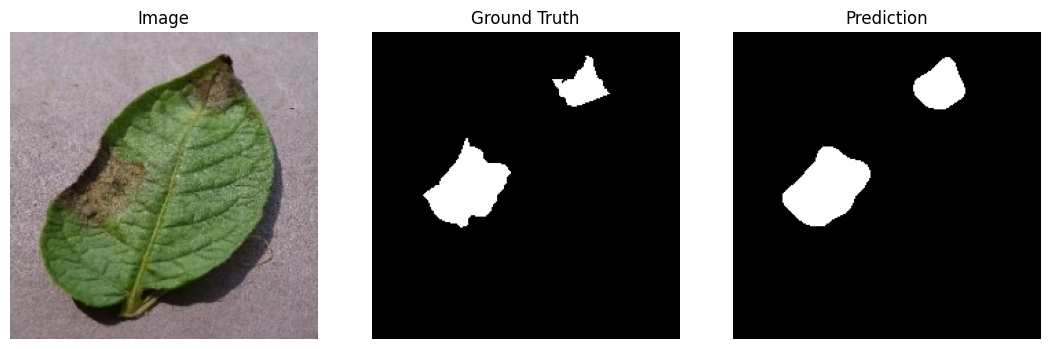

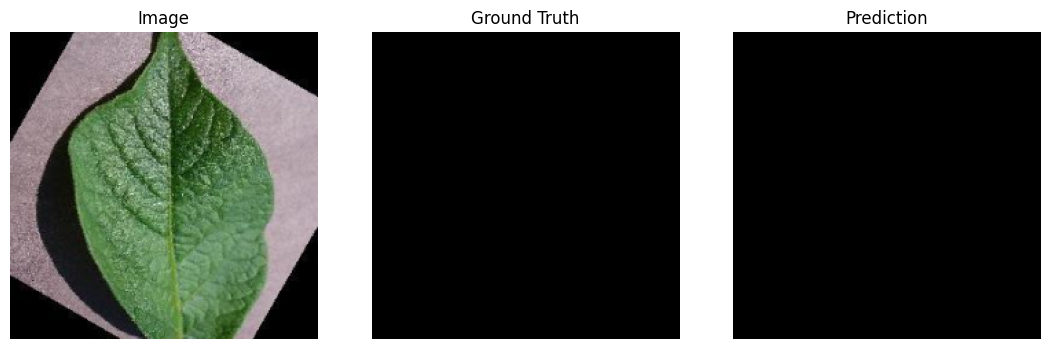

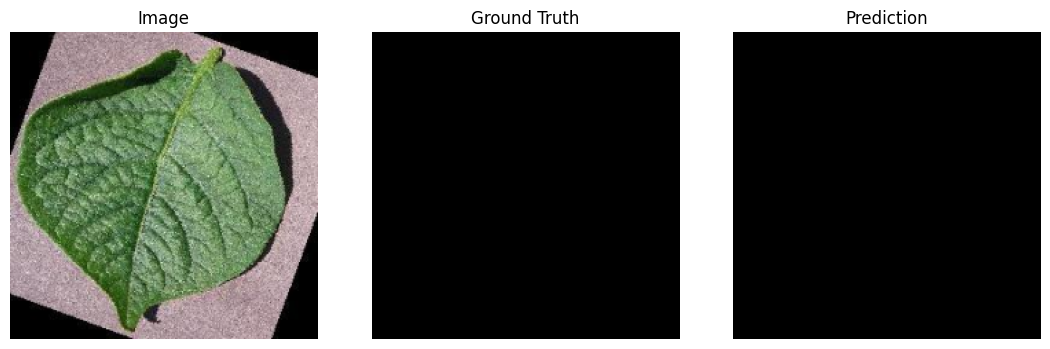

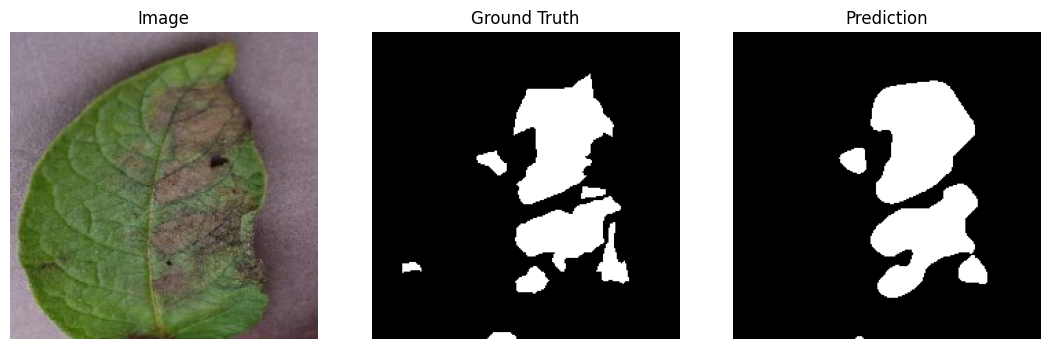

In [31]:
# ============================================================
# CELL 5
# B2: NAIVE IMAGE + 144-STEP ENVIRONMENT FUSION
# + FINAL COMPARISON
# ============================================================


# ------------------------------------------------------------
# Split
# ------------------------------------------------------------
train_f = fusion_df[
    fusion_df["split"] == "train"
].copy()

val_f = fusion_df[
    fusion_df["split"] == "valid"
].copy()

test_f = fusion_df[
    fusion_df["split"] == "test"
].copy()


print(
    "Fusion train pairs:",
    len(train_f)
)

print(
    "Fusion validation pairs:",
    len(val_f)
)

print(
    "Fusion test pairs:",
    len(test_f)
)


# ------------------------------------------------------------
# Dataloaders
# ------------------------------------------------------------
fusion_train_loader = DataLoader(

    FusionSegDataset(
        train_f,
        train_tfms()
    ),

    batch_size=BATCH_SIZE_FUSION,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True
)


fusion_val_loader = DataLoader(

    FusionSegDataset(
        val_f,
        val_tfms()
    ),

    batch_size=BATCH_SIZE_FUSION,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True
)


fusion_test_loader = DataLoader(

    FusionSegDataset(
        test_f,
        val_tfms()
    ),

    batch_size=BATCH_SIZE_FUSION,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True
)


# ------------------------------------------------------------
# B2 model
# ------------------------------------------------------------
B2_model = EfficientUNet(

    pretrained=True,

    fusion=True,

    env_hidden=128
)


print(
    "\nTraining B2..."
)


# ------------------------------------------------------------
# Train
# ------------------------------------------------------------
B2_model, B2_history = run_training(

    B2_model,

    fusion_train_loader,

    fusion_val_loader,

    fusion=True,

    name="B2_NaiveFusion_EfficientUNet_GRU"
)


# ------------------------------------------------------------
# Test
#
# 10 synthetic trajectories per image
# -> average their probability maps
# -> ONE prediction per image
# ------------------------------------------------------------
B2_test = evaluate(

    B2_model,

    fusion_test_loader,

    fusion=True,

    aggregate_image=True
)


# ------------------------------------------------------------
# Final table
# ------------------------------------------------------------
final_results = pd.DataFrame([

    {
        "Model":
            "B1 Image-only "
            "EfficientNet-B0 U-Net",

        **B1_test
    },

    {
        "Model":
            "B2 Naive Fusion "
            "(Image + 144h GRU)",

        **B2_test
    }

])


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
final_results.to_csv(

    RESULTS_DIR
    /
    "week3_baseline_comparison.csv",

    index=False
)


print(
    "\n=================================================="
)

print(
    "        WEEK-3 BASELINE RESULTS"
)

print(
    "=================================================="
)


print(
    final_results.to_string(
        index=False
    )
)


print(
    "\nResults saved in:"
)

print(
    RESULTS_DIR
)


# ============================================================
# OPTIONAL QUALITATIVE VISUALIZATION
# ============================================================
def show_predictions(
    model,
    loader,
    fusion=False,
    n=4
):

    model.eval()

    shown = 0


    with torch.no_grad():

        for batch in loader:

            images = batch[
                "image"
            ].to(DEVICE)


            env = batch.get(
                "env"
            )


            if fusion:

                env = env.to(
                    DEVICE
                )

                logits = model(
                    images,
                    env
                )

            else:

                logits = model(
                    images
                )


            predictions = (
                torch.sigmoid(
                    logits
                )
                .cpu()
                .numpy()[:,0]
            )


            ground_truth = (
                batch[
                    "mask"
                ]
                .numpy()[:,0]
            )


            for i in range(
                len(predictions)
            ):

                if shown >= n:
                    return


                fig, ax = plt.subplots(
                    1,
                    3,
                    figsize=(11, 3.5)
                )


                image = (
                    batch["image"][i]
                    .permute(1,2,0)
                    .numpy()
                )


                image = np.clip(

                    image
                    *
                    np.array(
                        IMG_STD
                    )

                    +

                    np.array(
                        IMG_MEAN
                    ),

                    0,
                    1
                )


                ax[0].imshow(
                    image
                )

                ax[0].set_title(
                    "Image"
                )


                ax[1].imshow(
                    ground_truth[i],
                    cmap="gray"
                )

                ax[1].set_title(
                    "Ground Truth"
                )


                ax[2].imshow(
                    predictions[i] >= 0.5,
                    cmap="gray"
                )

                ax[2].set_title(
                    "Prediction"
                )


                for a in ax:
                    a.axis("off")


                plt.tight_layout()
                plt.show()


                shown += 1


# ------------------------------------------------------------
# B1 qualitative result
# ------------------------------------------------------------
show_predictions(
    B1_model,
    img_test_loader,
    fusion=False,
    n=4
)